--- Точність моделей на тестових даних ---
Штучна нейронна мережа: 1.00
Лінійна (логістична) регресія: 1.00
Дерево рішень: 1.00

--- Правила Дерева рішень (логіка 'якщо-то') ---
|--- Вік <= 26.50
|   |--- class: відмовити
|--- Вік >  26.50
|   |--- class: видати



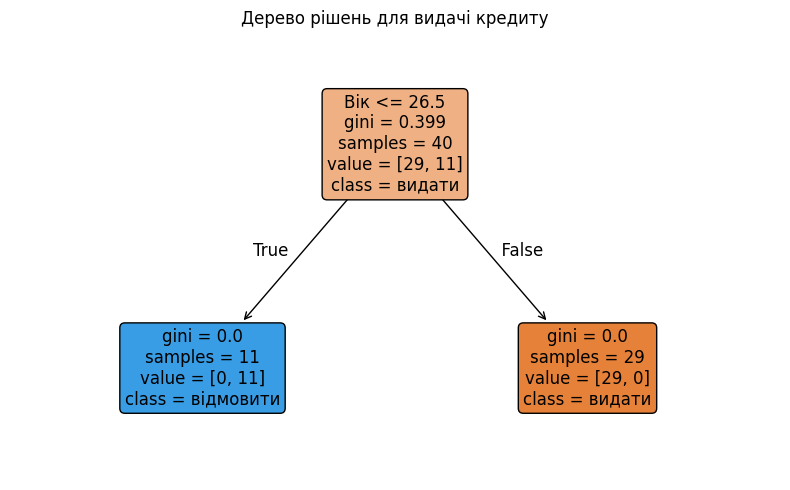

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import tree

#1. Імпорт даних
df = pd.read_csv('Lab6.txt', sep='\t') 

# Вхідні параметри та вихідний клас
X = df[['Вік', 'Стаж_роботи_роки', 'Дохід_тис_грн', 'Вартість_авто_тис_грн']]
y = df['Рішення']

# Розбиваємо дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2. Мастабування даних
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#3. Побудова моделей
# Ускладнили архітектуру та збільшили ліміт ітерацій
nn_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=2000, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# Лінійна регресія
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Дерево рішень 
tree_model = DecisionTreeClassifier(max_depth=4, min_samples_split=4, random_state=42)
tree_model.fit(X_train, y_train)

#4. Оцінка моделей
print("--- Точність моделей на тестових даних ---")
print(f"Нейронна мережа: {accuracy_score(y_test, nn_model.predict(X_test_scaled)):.2f}")
print(f"Лінійна регресія: {accuracy_score(y_test, lr_model.predict(X_test_scaled)):.2f}")
print(f"Дерево рішень: {accuracy_score(y_test, tree_model.predict(X_test)):.2f}\n")

#5. Візуалізація
print("Правила Дерева рішень")
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(8, 5)) 
tree.plot_tree(tree_model, 
               feature_names=list(X.columns), 
               class_names=tree_model.classes_, 
               filled=True, 
               rounded=True,
               fontsize=12)

plt.title("Дерево рішень для видачі кредиту")
plt.tight_layout()
plt.show()